In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("property_data_update.csv", index_col=None)

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


In [4]:
data.head(5)

,address,zip_code,residential_units,total_units,plot_size,total_builtup_area,age_property,dist_landmarks,dist_postoffice,sell_price
0,"327 EAST 3 STREET, 1C",10009.0,1.0,1.0,2000.0,2700.0,12.0,34.7000,104.069137,675000.0
1,"327 EAST 3RD STREET, 5A",10009.0,1.0,1.0,1185.0,1264.0,104.0,34.6185,16.203313,765000.0
2,"327 EAST 3 STREET, 2E",10009.0,1.0,1.0,2143.0,1700.0,12.0,36.5143,32.764258,819000.0
3,"317 EAST 3RD STREET, 12",10009.0,1.0,1.0,2500.0,600.0,105.0,31.3550,109.590097,453150.0
4,"311 EAST 3RD STREET, 17",10009.0,1.0,1.0,1275.0,2294.0,97.0,32.1275,7.506365,480000.0


In [5]:
data.columns

Index(['address', 'zip_code', 'residential_units', 'total_units', 'plot_size',
       'total_builtup_area', 'age_property', 'dist_landmarks',
       'dist_postoffice ', 'sell_price'],
      dtype='object')

In [6]:
data.describe().round(2)

,zip_code,residential_units,total_units,plot_size,total_builtup_area,age_property,dist_landmarks,dist_postoffice,sell_price
count,10873.00,10873.00,10873.00,10873.00,10873.00,10873.00,10873.00,10873.00,10873.00
mean,9872.03,1.49,1.52,2680.44,1668.16,71.12,32.87,53.14,588202.40
std,1222.19,0.62,0.62,891.12,520.05,30.56,4.70,37.43,116821.83
min,0.00,0.00,1.00,200.00,0.00,1.00,23.01,2.64,415000.00
25%,10011.00,1.00,1.00,2000.00,1280.00,55.00,29.33,24.29,485000.00
50%,10017.00,1.00,1.00,2500.00,1600.00,77.00,32.57,44.78,570000.00
75%,10025.00,2.00,2.00,3292.00,2023.00,92.00,36.25,72.83,680000.00
max,10463.00,4.00,4.00,4998.00,2999.00,147.00,45.07,340.43,830000.00


In [7]:
data.describe(include='object').T

,count,unique,top,freq
address,10873,6607,30 PARK PLACE,90


We have two features 'address' and 'zip_code' which represent the geo location of the property,we are not going to use these features for the current anaylsis. 

In [8]:
data.drop(['zip_code','address'],axis=1,inplace=True)

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10874 entries, 0 to 10873
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   residential_units   10873 non-null  float64
 1   total_units         10873 non-null  float64
 2   plot_size           10873 non-null  float64
 3   total_builtup_area  10873 non-null  float64
 4   age_property        10873 non-null  float64
 5   dist_landmarks      10873 non-null  float64
 6   dist_postoffice     10873 non-null  float64
 7   sell_price          10873 non-null  float64
dtypes: float64(8)
memory usage: 679.8 KB


In [10]:
dups = data.duplicated()
print('Number of duplicate rows = %d' % (dups.sum()))

Number of duplicate rows = 0


In [11]:
data.isnull().sum() 

residential_units     1
total_units           1
plot_size             1
total_builtup_area    1
age_property          1
dist_landmarks        1
dist_postoffice       1
sell_price            1
dtype: int64

In [12]:
data[data.isnull().any(axis=1)]

,residential_units,total_units,plot_size,total_builtup_area,age_property,dist_landmarks,dist_postoffice,sell_price
6750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
data.dropna(inplace=True) # We have a blank row in the dataset 
data.isnull().sum() 

residential_units     0
total_units           0
plot_size             0
total_builtup_area    0
age_property          0
dist_landmarks        0
dist_postoffice       0
sell_price            0
dtype: int64

#### Univariate analysis- 

In [14]:
data.columns


Index(['residential_units', 'total_units', 'plot_size', 'total_builtup_area',
       'age_property', 'dist_landmarks', 'dist_postoffice ', 'sell_price'],
      dtype='object')

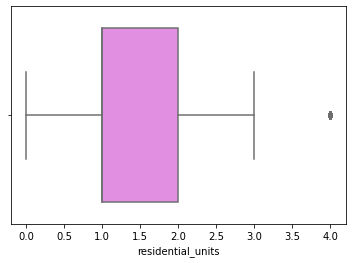

In [15]:
sns.boxplot(data['residential_units'], color="violet") 
plt.show()

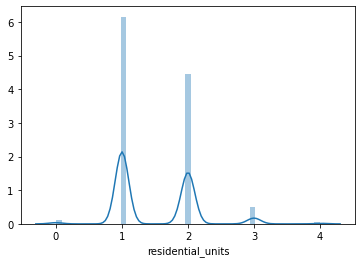

In [16]:
sns.distplot(data['residential_units'],kde=True)
plt.show()

In [17]:
data['residential_units'].describe()

count    10873.000000
mean         1.487078
std          0.617714
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: residential_units, dtype: float64

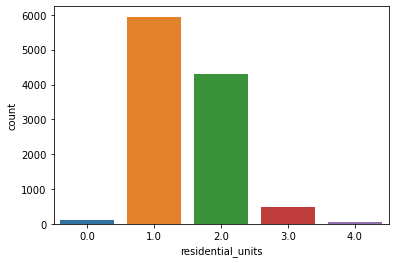

In [18]:
sns.countplot(x= data.residential_units)
plt.show()

In [19]:
data['residential_units'].skew().round(3)

0.759

In [20]:
data['residential_units'].kurt().round(3)

0.45

In [21]:
data.residential_units.value_counts()

1.0    5944
2.0    4305
3.0     477
0.0     101
4.0      46
Name: residential_units, dtype: int64

#### Inferences - 
 
1. Min value is 0 while Max is 4. 
2. Most number of buildings have either 1 or 2 residential units. Very few have as high as 4 residential units. 
3. Buildings with 4 Residential units are outliers. 

### 2. Total Units 

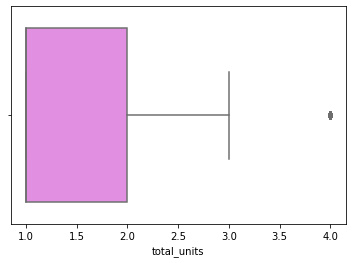

In [22]:
sns.boxplot(data['total_units'], color="violet") 
plt.show()


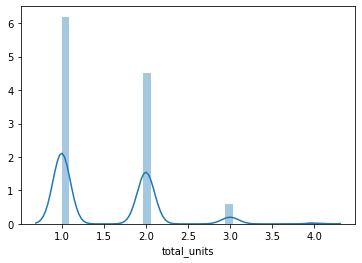

In [23]:
sns.distplot(data['total_units'],kde=True)
plt.show()

In [24]:
data['total_units'].describe()

count    10873.000000
mean         1.515681
std          0.619434
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          4.000000
Name: total_units, dtype: float64

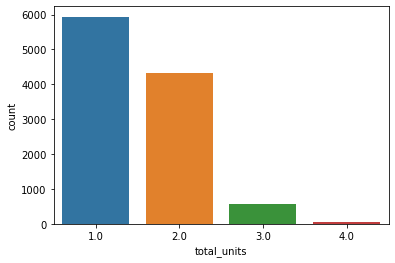

In [25]:
sns.countplot(x= data['total_units'])
plt.show()

In [26]:
data['total_units'].skew().round(3)

0.918

In [27]:
data['total_units'].kurt().round(3)

0.458

#### Total Units  -  
1. Min value is 1 while Max is 4. 
2.  Similar to residential units, most number of buildings have either 1 or 2 Total Units. Very few have as high as 4 total units. 
3. Buildings with 4 Total units are outliers. 

### 3. Plot Size ( Sq. Feet) 

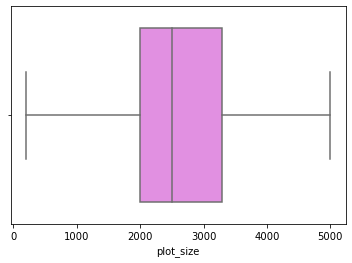

In [28]:
sns.boxplot(data['plot_size'], color="violet") 
plt.show()


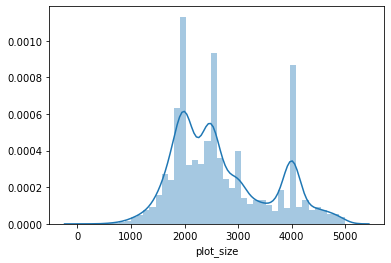

In [29]:
sns.distplot(data['plot_size'],kde=True)
plt.show()

In [30]:
data['plot_size'].describe()

count    10873.000000
mean      2680.435850
std        891.121548
min        200.000000
25%       2000.000000
50%       2500.000000
75%       3292.000000
max       4998.000000
Name: plot_size, dtype: float64

In [31]:
data['plot_size'].skew().round(3)

0.606

In [32]:
data['plot_size'].kurt().round(3)

-0.57

#### Plot Size  -  
1. Min value is 200 sq feet while Max is close to 5000 sq feet. 
2. Mean of 2680 is higher than the Median value 2500. With std. deviation of 891, the CV is close to 0.3, thus low variation present. 
3. Clearly a Multimodal distribution, with peaks at approx. 2000, 2500 and 4000 sq. feet levels. 
4. No outliers present in the distribution. 

### 4. Total Builtup Area

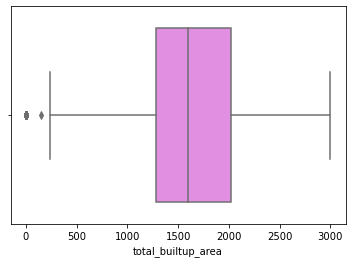

In [33]:
sns.boxplot(data['total_builtup_area'], color="violet") 
plt.show()


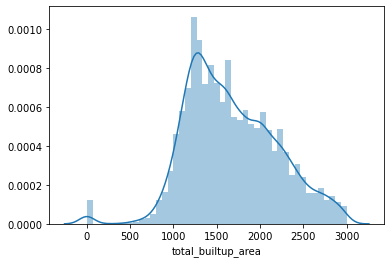

In [34]:
sns.distplot(data['total_builtup_area'],kde=True)
plt.show()

In [35]:
data['total_builtup_area'].describe()

count    10873.000000
mean      1668.158558
std        520.051835
min          0.000000
25%       1280.000000
50%       1600.000000
75%       2023.000000
max       2999.000000
Name: total_builtup_area, dtype: float64

In [36]:
data['total_builtup_area'].skew().round(3)

0.23

In [37]:
data['total_builtup_area'].kurt().round(3)

0.067

#### Total Builtup Area  -  
1. Min value is 0 sq feet(Odd)  while Max is close to 3000 sq feet. 
2. Mean of 1668 is approx. equal to Median value 1680. With std. deviation of 520, the CV is again close to 0.3, thus low variation present. 
3. Few outliers present in the left tail of the distribution. (Values lesser than Mean) 

### 5. Age Property 

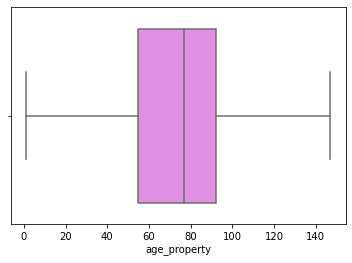

In [38]:
sns.boxplot(data['age_property'], color="violet") 
plt.show()


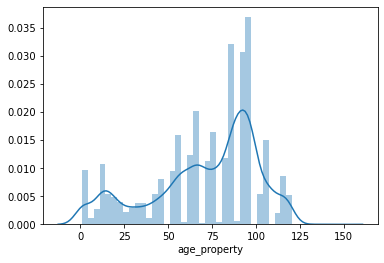

In [39]:
sns.distplot(data['age_property'],kde=True)
plt.show()

In [40]:
data['age_property'].describe()

count    10873.000000
mean        71.116803
std         30.557768
min          1.000000
25%         55.000000
50%         77.000000
75%         92.000000
max        147.000000
Name: age_property, dtype: float64

In [41]:
data['age_property'].skew().round(3)

-0.72

In [42]:
data['age_property'].kurt().round(3)

-0.396

#### Age Property  -  
1. Min age of properties is 1 yrs while the oldest buildings have age close to 147 yrs.  
2. Mean of 71 yrs is approx. equal to Median value 77. With std. deviation of 30, the CV is close to 0.42, thus higher variation than plot_size and total_builtup_area. 
3. No outliers present in the distribution.
4. Age can also be considered a Multimodal distribution, with three peaks at approx. 90-100 yrs, 50-75yrs and 0-25 yrs levels. 

### 6. Dist Landmarks 

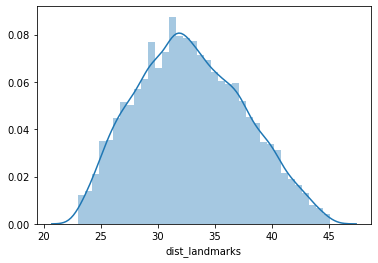

In [43]:
sns.distplot(data['dist_landmarks'],kde=True)
plt.show()



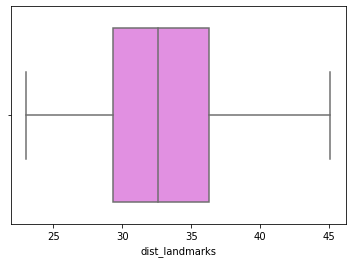

In [44]:
sns.boxplot(data['dist_landmarks'], color="violet") 
plt.show()


In [45]:
data['dist_landmarks'].describe()

count    10873.000000
mean        32.873595
std          4.696109
min         23.011833
25%         29.329700
50%         32.573333
75%         36.250000
max         45.066667
Name: dist_landmarks, dtype: float64

In [46]:
data['dist_landmarks'].skew().round(3)

0.195

In [47]:
data['dist_landmarks'].kurt().round(3)

-0.63

#### Distance to Landmarks  -  
1. Min distance is 23 miles while the max distance is 45 miles.   
2. Mean of 32.8 is approx. equal to Median value 32.5. With std. deviation of 4.6, the CV is close to 0.13, thus lowest variation so far.  
3. No outliers present in the distribution.
4. With a fair bit of approximation, Distance to landmarks can be considered as a Symmetric distribution.  

### 7. Dist Postoffice 

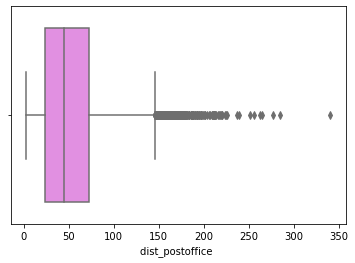

In [48]:
sns.boxplot( data['dist_postoffice '], color="violet") 
plt.show()

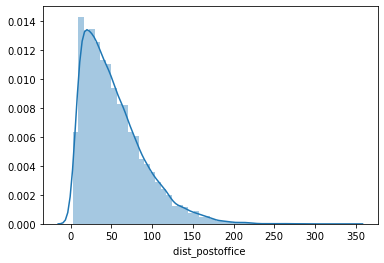

In [49]:
sns.distplot( data['dist_postoffice '],kde=True)
plt.show()

In [50]:
data['dist_postoffice '].describe()

count    10873.000000
mean        53.141183
std         37.434208
min          2.636149
25%         24.288220
50%         44.784438
75%         72.826716
max        340.428964
Name: dist_postoffice , dtype: float64

In [51]:
data['dist_postoffice '].skew()

1.2621230529825238

In [52]:
data['dist_postoffice '].kurt()

2.121505180236541

#### Distance to Post office  -  
1. Min distance is 2.6 miles while the max distance is 340 miles.   
2. Mean of 53.14 is greater than Median value 44.7. With std. deviation of 37.43, the CV is close to 0.7, thus highest variation so far.  
3. Few outliers are present in the right tail of the distribution. (Percentage outliers will be analyzed in subsequent sections)
4. Positive skewness evident from the long right tail, skewness is 1.26 .  

### 8. Sell Price - Target Variable 

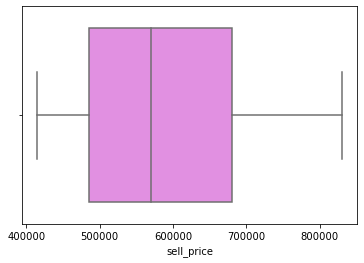

In [53]:
sns.boxplot( data['sell_price'], color="violet") 
plt.show()

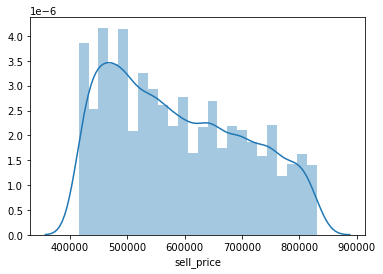

In [54]:
sns.distplot( data['sell_price'],kde=True)
plt.show()

In [55]:
data['sell_price'].describe()

count     10873.000000
mean     588202.403201
std      116821.830617
min      415000.000000
25%      485000.000000
50%      570000.000000
75%      680000.000000
max      830000.000000
Name: sell_price, dtype: float64

In [56]:
data['sell_price'].skew()

0.34909009981946826

In [57]:
data['sell_price'].kurt()  

-1.0397968764249301

#### Distance to Post office  -  
1. Min sell price is 415000 USD while the max is 830000 USD.   
2. Mean of 588202 is approx. equal to Median value 570000. With std. deviation of 116821, the CV is close to 0.2, thus low variation present.  
3. No outliers are present in the distribution.
4. Sell price has Negative kurtosis, i.e. platykurtic distribution.( Reference Kurtosis for Normal is 0.0 in pandas kurt() function)

### Analysis of Variation - 
The coefficient of variation (relative standard deviation) is a statistical measure of the dispersion of data points around the mean. Higher value indicates greater spread. It can be used to compare variation among data series with different means. 

In [58]:
CV_data = pd.DataFrame(data = [data.std().values,data.mean().values,data.std().values/data.mean().values] , columns=data.columns , index = ['Std Dev','Mean','CV'] ).T

In [59]:
CV_data.sort_values(by='CV',ascending=False).round(3)

,Std Dev,Mean,CV
dist_postoffice,37.434,53.141,0.704
age_property,30.558,71.117,0.430
residential_units,0.618,1.487,0.415
total_units,0.619,1.516,0.409
plot_size,891.122,2680.436,0.332
total_builtup_area,520.052,1668.159,0.312
sell_price,116821.831,588202.403,0.199
dist_landmarks,4.696,32.874,0.143


Dist_Postoffice has the highest value of Coeffecient of Variation at 0.704, while dist_landmarks has the lowest CV of 0.143.

### Percentage Outliers - 

In [60]:
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
pd.DataFrame((((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).sum()/data.shape[0]*100).round(2),columns=['Outliers %'])

,Outliers %
residential_units,0.42
total_units,0.52
plot_size,0.00
total_builtup_area,0.83
age_property,0.00
dist_landmarks,0.00
dist_postoffice,2.62
sell_price,0.00


As the percentage outliers are very low (2.62% being the highest), we will not be doing outlier treatment or removal for the current analysis. An outlier percentage of order of 15-20% is a cause for concern thus must be thoroughly investigated. 

### Multivariate Analysis - 

### Pair plot- 
A pairs plot allows us to see both distribution of single variables and relationships between two variables. Pair plots are a great method to identify trends for follow-up analysis. The histogram on the diagonal allows us to see the distribution of a single variable while the scatter plots on the upper and lower triangles show the relationship (or lack thereof) between two variables. 

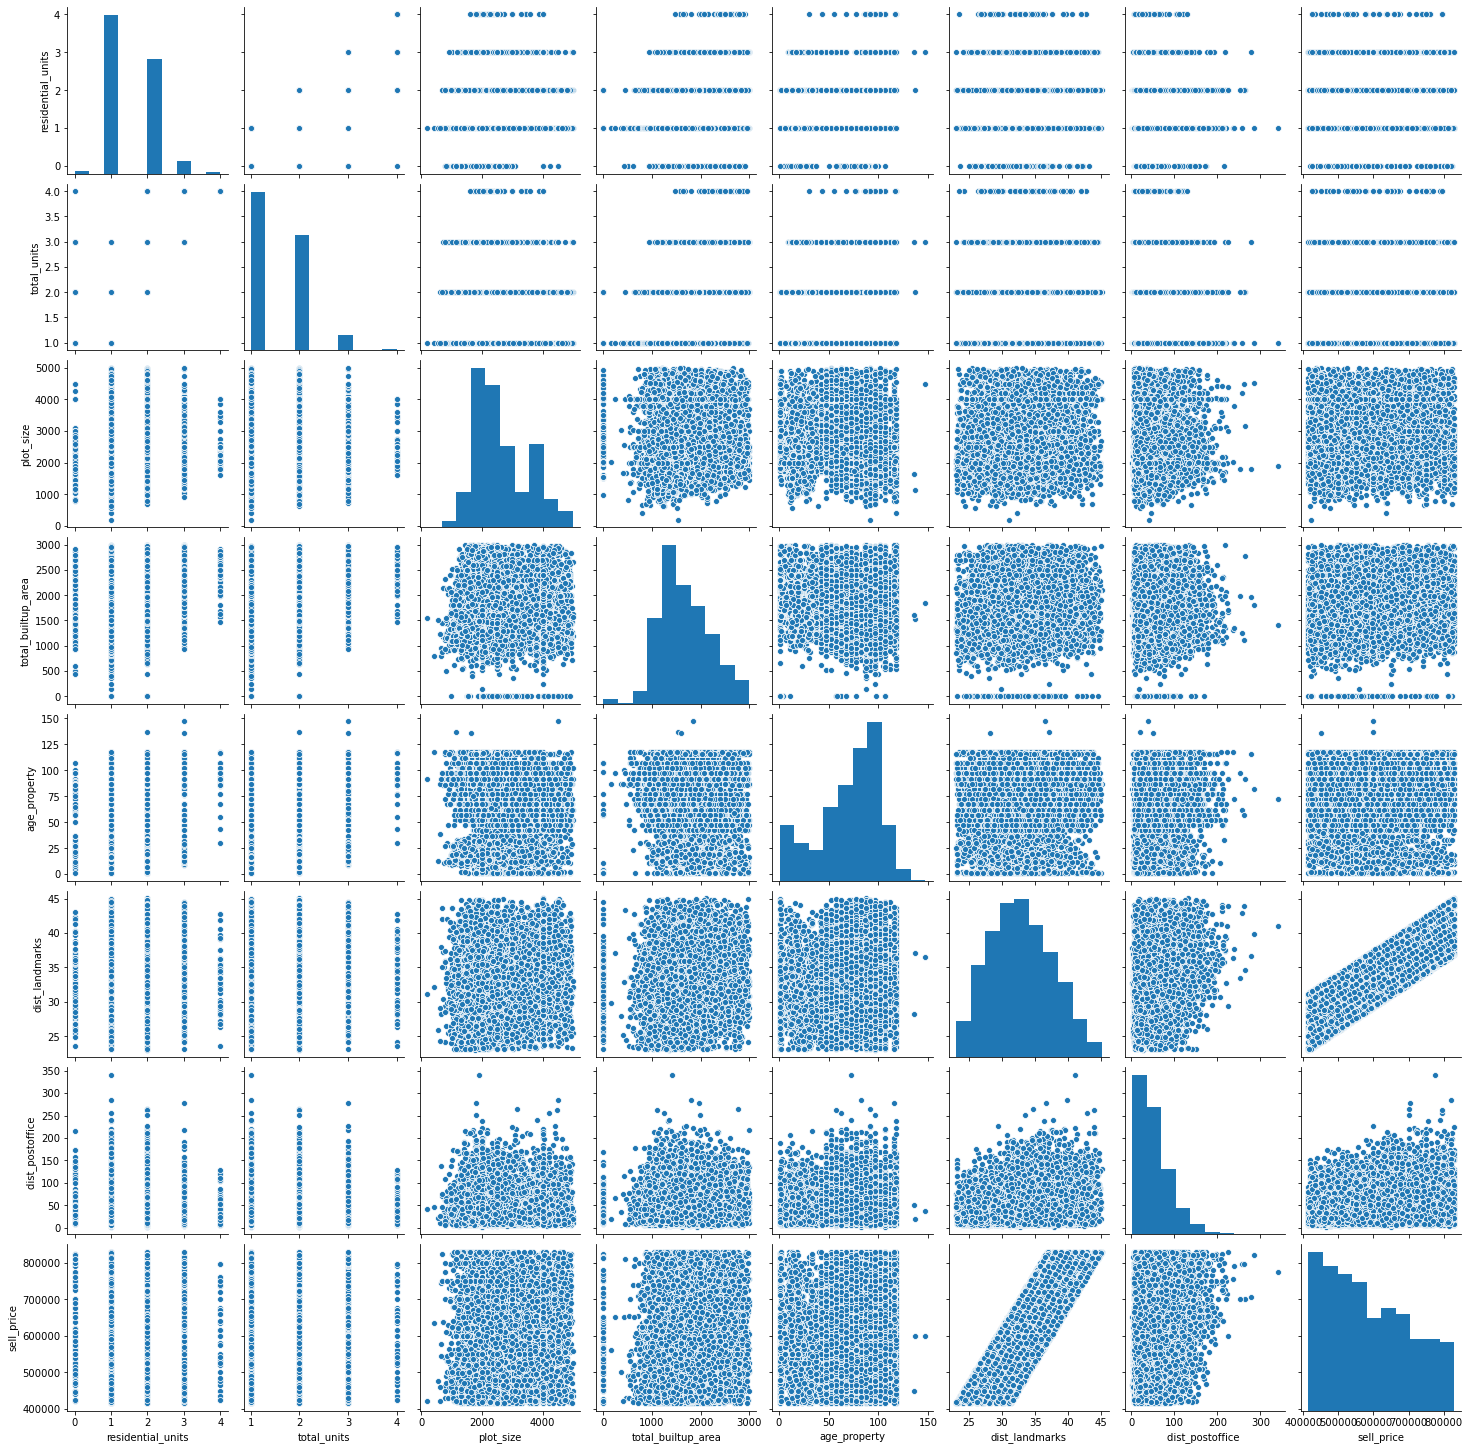

In [61]:
sns.pairplot(data)
plt.show()

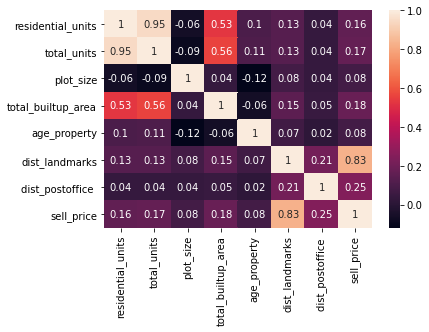

In [62]:
cor = data.corr().round(2)
sns.heatmap(cor, annot=True)
plt.show()

### Inferences- 

Top Positive Correlation Pairs  - 
1. residential_units and total_units (+0.95) 
2. dist_landmarks and sell_price (+0.83) 
3. total_builtup_area and total_units (Moderate correlation +0.56) 

Negative correlations are not significant, highest being -0.12 between age_property and plot_size. 

As we have seen, we have few pairs of features with significant positive correlations. We will perform Principal Component Analysis to handle the issue of Multicollinearity. PCA is also useful when the features are too many, and we want to reduce the feature set without losing a significant amount of information (variability). 

Lets first train a Linear Regression model on original features, and then compare the model perfromance with a Model trained on Optimum no. of Principal Components. 

### Linear Regression Model with original features -

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
X = data.drop(['sell_price'],axis=1)
y = data['sell_price']

In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=10,test_size=0.2) 

In [66]:
X_train.shape,X_test.shape

((8698, 7), (2175, 7))

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [68]:
LR = LinearRegression()
LR.fit(X_train,y_train)

LinearRegression()

In [69]:
y_train_pred = LR.predict(X_train)

In [70]:
y_test_pred = LR.predict(X_test)

### RMSE values - 

In [71]:
np.sqrt(mean_squared_error(y_true = y_train, y_pred =y_train_pred )).round(3)

63220.434

In [72]:
np.sqrt(mean_squared_error(y_true = y_test, y_pred =y_test_pred )).round(3)

64310.227

### R^2 Scores - 

In [73]:
r2_score(y_true = y_train, y_pred =y_train_pred ).round(3)

0.706

In [74]:
r2_score(y_true = y_test, y_pred =y_test_pred ).round(3)

0.702

### Adj. R2 Scores - 

<img src="http://www.haghish.com/statistics/stata-blog/stata-programming/images/adjr2.png" width="400" height="200" />

##### For Train Set- 

In [75]:
n = X_train.shape[0]
k = X_train.shape[1]
r2 = r2_score(y_true = y_train, y_pred =y_train_pred )

In [76]:
1 - ((1- r2)*(n-1)/(n-k-1))

0.7054634506146522

##### For Test Set- 

In [77]:
n = X_test.shape[0]
k = X_test.shape[1]
r2 = r2_score(y_true = y_test, y_pred =y_test_pred )

In [78]:
1 - ((1- r2)*(n-1)/(n-k-1))

0.701485555202376

We have obtained R2 scores of 0.70 on both Train and Test set, thus the model is fairly generalised i.e. performs equally well on unseen data (test data) as it does on the training data. 


# Regularization techniques

In [79]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
ridge = Ridge(alpha = 0.1,normalize = True)
lasso = Lasso(alpha = 0.1,normalize = True)
elasticnet = ElasticNet(l1_ratio=0.5,alpha = 0.0001,normalize = True)

### Ridge model

(array([0, 1, 2, 3, 4, 5, 6]), <a list of 7 Text major ticklabel objects>)

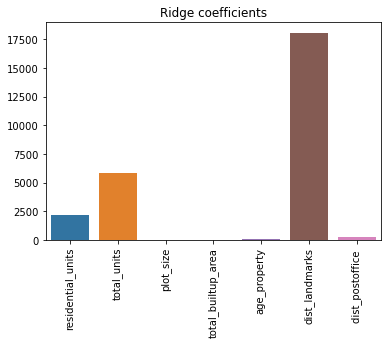

In [80]:
model = ridge.fit(X_train,y_train)
sns.barplot(x = X_train.columns,y = model.coef_)
plt.title('Ridge coefficients')
plt.xticks(rotation = 90)

### Lasso model

(array([0, 1, 2, 3, 4, 5, 6]), <a list of 7 Text major ticklabel objects>)

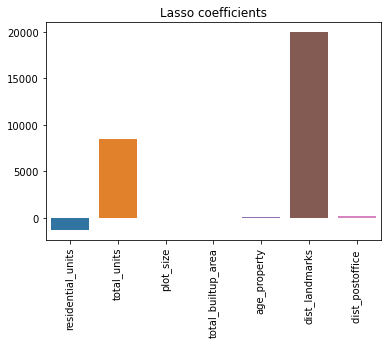

In [81]:
model = lasso.fit(X_train,y_train)
sns.barplot(x = X_train.columns,y = model.coef_)
plt.title('Lasso coefficients')
plt.xticks(rotation = 90)

### Elasticnet model

(array([0, 1, 2, 3, 4, 5, 6]), <a list of 7 Text major ticklabel objects>)

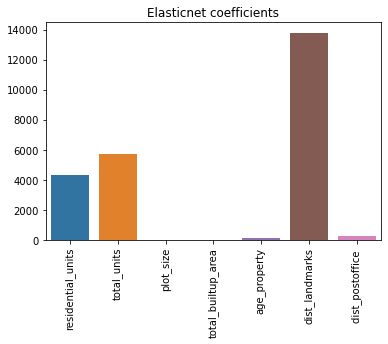

In [82]:
model = elasticnet.fit(X_train,y_train)
sns.barplot(x = X_train.columns,y = model.coef_)
plt.title('Elasticnet coefficients')
plt.xticks(rotation = 90)

### K-fold cross validation

In [83]:
from sklearn.model_selection import KFold
from sklearn import metrics
kf = KFold(n_splits=10,shuffle=True,random_state=0)
for model,name in zip([LR,ridge,lasso,elasticnet],['Linear_Regression','Ridge','LASSO','ElasticNet']):
    rmse = []
    for train_idx,test_idx in kf.split(X,y):
        X_train,X_test = X.iloc[train_idx,:],X.iloc[test_idx,:]
        y_train,y_test = y.iloc[train_idx],y.iloc[test_idx]
        model.fit(X_train,y_train)
        y_pred = model.predict(X_test)
        mse = metrics.mean_squared_error(y_test,y_pred)
        rmse.append(np.sqrt(mse))
    print('RMSE scores : %0.03f (+/- %0.08f) [%s]'%(np.mean(rmse), np.std(rmse,ddof = 1), name))
    print()

RMSE scores : 63470.173 (+/- 1363.30465336) [Linear_Regression]

RMSE scores : 64052.831 (+/- 1433.97264425) [Ridge]

RMSE scores : 63470.146 (+/- 1362.57463200) [LASSO]

RMSE scores : 70541.176 (+/- 1629.97837422) [ElasticNet]



Now lets apply PCA to the data set, and then use the obtained PCs to train a Linear Regression Model.  

### PCA - 

In [84]:
from sklearn.decomposition import PCA
pca = PCA(random_state=100)

In [85]:
X_train.shape,X_test.shape    # Split made in previous section

((9786, 7), (1087, 7))

PCA is affected by scale so we need to scale the features in data before applying PCA. We will be using StandardScaler to help standardize the dataset’s features onto unit scale (mean = 0 and variance = 1) which is a requirement for the optimal performance of PCA. 

The standard score of a sample x is calculated as:

z = (x - u) / s

where u is the mean of the training samples and s is the standard deviation of the training sample. Centering and scaling happen independently on each feature by computing the relevant statistics on the samples in the training set. Mean and standard deviation are then stored to be used on later data using transform.

In [86]:
from sklearn.preprocessing import StandardScaler   # Scaling is necessary for PCA

In [87]:
std = StandardScaler()

In [88]:
X_train_sc = pd.DataFrame(std.fit_transform(X_train),columns= X_train.columns)  #Fitting the scaler object

In [89]:
X_test_sc = pd.DataFrame(std.transform(X_test),columns= X_test.columns)    # Transforming the Test set using scaler object 

In [90]:
X_train_sc.describe()

,residential_units,total_units,plot_size,total_builtup_area,age_property,dist_landmarks,dist_postoffice
count,9.786000e+03,9.786000e+03,9.786000e+03,9.786000e+03,9.786000e+03,9.786000e+03,9.786000e+03
mean,-9.785165e-15,-7.230631e-16,-9.644441e-15,-6.978999e-16,1.780178e-14,1.187449e-15,-6.375898e-17
std,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00,1.000051e+00
min,-2.403135e+00,-8.286894e-01,-2.790203e+00,-3.205714e+00,-2.295458e+00,-2.098983e+00,-1.352762e+00
25%,-7.842817e-01,-8.286894e-01,-7.666415e-01,-7.419060e-01,-5.587513e-01,-7.575785e-01,-7.700970e-01
50%,-7.842817e-01,-8.286894e-01,-2.045410e-01,-1.259540e-01,1.949140e-01,-6.431802e-02,-2.214764e-01
75%,8.345711e-01,7.874036e-01,6.911660e-01,6.747836e-01,6.864349e-01,7.200337e-01,5.302564e-01
max,4.072277e+00,4.019590e+00,2.603713e+00,2.566911e+00,2.488678e+00,2.597509e+00,7.680923e+00


In [91]:
pca_columns = ['PC1','PC2','PC3','PC4','PC5','PC6','PC7']

In [92]:
train_pca_data = pd.DataFrame(pca.fit_transform(X_train_sc) , columns =pca_columns)# PCA will be conducted on X set only. 

In [93]:
test_pca_data = pd.DataFrame(pca.transform(X_test_sc),columns= pca_columns)

#### Variance Explained - 

In [94]:
pca.explained_variance_ratio_

array([0.3485625 , 0.17527474, 0.16050571, 0.12496457, 0.10879186,
       0.07564619, 0.00625442])

In [95]:
var = (np.array([pca.explained_variance_ratio_[:i].sum() for i in range(1, 8)])*100).round(2) 

In [96]:
var

array([ 34.86,  52.38,  68.43,  80.93,  91.81,  99.37, 100.  ])

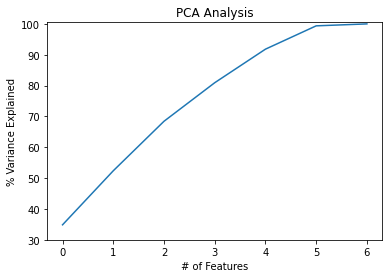

In [97]:
plt.ylabel('% Variance Explained')
plt.xlabel('# of Features')
plt.title('PCA Analysis')
plt.ylim(30,100.5)
plt.style.context('seaborn-whitegrid')
plt.plot(var)
plt.show()

The Cumulative % gives the percentage of variance accounted for by the n components. For example, the cumulative percentage for the second component is the sum of the percentage of variance for the first and second components. It helps in deciding the number of components by selecting the components which explained the variance required. 

In the above array we see that the first feature explains 34% of the variance within our data set while the first two explain 52.38 and so on. If we use 5 features we capture 91.71% of the variance within the dataset. 

In [98]:
train_pca_data_5 = train_pca_data.iloc[:,:5] #selecting 5 PCs

In [99]:
test_pca_data_5 = test_pca_data.iloc[:,:5]  #selecting 5 PCs

In [100]:
train_pca_data_5.shape

(9786, 5)

In [101]:
train_pca_data_5.corr().round(2)

,PC1,PC2,PC3,PC4,PC5
PC1,1.0,-0.0,0.0,0.0,0.0
PC2,-0.0,1.0,0.0,-0.0,-0.0
PC3,0.0,0.0,1.0,0.0,-0.0
PC4,0.0,-0.0,0.0,1.0,0.0
PC5,0.0,-0.0,-0.0,0.0,1.0


Now that we have obtained Principal Components with No correlations among them, we shall use them to train Linear Regression Model.

#### Linear Regression Model using the chosen 5 Principal Components - 

In [102]:
LR_pca = LinearRegression()
LR_pca.fit(train_pca_data_5,y_train)

LinearRegression()

In [103]:
y_train_pred_pca = LR_pca.predict(train_pca_data_5)

In [104]:
y_test_pred_pca = LR_pca.predict(test_pca_data_5)

### RMSE values - 

In [105]:
np.sqrt(mean_squared_error(y_true = y_train, y_pred =y_train_pred_pca )).round(3)

63712.053

In [106]:
np.sqrt(mean_squared_error(y_true = y_test, y_pred =y_test_pred_pca )).round(3)

64034.643

### R^2 Scores - 

In [107]:
r2_score(y_true = y_train, y_pred =y_train_pred_pca ).round(3)

0.703

In [108]:
r2_score(y_true = y_test, y_pred =y_test_pred_pca ).round(3)

0.696

### Adj. R2 Scores - 

<img src="http://www.haghish.com/statistics/stata-blog/stata-programming/images/adjr2.png" width="400" height="200" />

In [109]:
n = train_pca_data_5.shape[0]
k = train_pca_data_5.shape[1]
r2 = r2_score(y_true = y_train, y_pred =y_train_pred_pca )

In [110]:
1 - ((1- r2)*(n-1)/(n-k-1))

0.7027980844845294

In [111]:
n = test_pca_data_5.shape[0]
k = test_pca_data_5.shape[1]
r2 = r2_score(y_true = y_test, y_pred =y_test_pred_pca )

In [112]:
1 - ((1- r2)*(n-1)/(n-k-1))

0.6941403501676526

In [113]:
2/7

0.2857142857142857

#### Conclusion - 

We have obtained a very similar R2 scores (and Adj. R2) of 0.70 on both Train and Test set, when compared to  the first model(LR with original features).We observe that even after reducing the number of predictors by approximately 30% ( 2/7 = 0.28), the model performance did not deteriorate. This shows us the strength of PCA, PCA was successfully used to reduce the noise from the dataset, without compromising with the model performance. It also reomved the multicollinearity present in the original dataset.  
